In [1]:
import torch
import matplotlib.pyplot as plt
import math
import scipy.io
import numpy as np
from langevinDynamics.core import doSimulation, SimulationParameters, sample_gmm_efficient
torch.manual_seed(42)

# Set device
device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


In [2]:
# ─── Parameters ────────────────────────────────────────────────
dt = 1e-2             # Time step
num_steps = 200           # Total steps
T = num_steps * dt          # Total time
num_particles = 1*10**7       # Reduced for performance
small_region_radius = 0.08  # Increased radius

mat = scipy.io.loadmat('data/initialData.mat')['initialData']
small_region_centers = torch.from_numpy(mat)

In [3]:
# ─── GMM for X0 (initial distribution) ─────────────────────────
std0 = math.sqrt(1.0)
weightsX0 = torch.tensor([1.0], device=device)
mu_X0 = torch.tensor([[0.,0.]], device=device)
covariances_X0 = torch.tensor([[[std0**2,0.],[0.,std0**2]]], device=device)

# ─── GMM for Xinf (final/target distribution) ──────────────────
weightsXinf = torch.tensor([0.0], device=device)
mu_Xinf = torch.tensor([[0.,0.]], device=device)
inv_covariances_T = torch.zeros_like(torch.eye(2, device=device).unsqueeze(0))
det_T = 0.0

In [4]:
# ─── Initialize particles from initial GMM ─────────────────────
positions = sample_gmm_efficient(weightsX0, mu_X0, covariances_X0, num_particles)

In [5]:
boolMask = np.empty(small_region_centers.shape[0], dtype=bool)

# Check if there are particles inside the small regions 
for center in range(small_region_centers.shape[0]):
    distances = torch.norm(positions - small_region_centers[center, :], dim=1)
    masks = distances < small_region_radius
    num_selected = masks.sum().item()
    boolMask[center] = num_selected > 10
    print(f"Number of particles in small region: {num_selected}")

# Store initial positions for visualization
positions1 = positions.clone()
small_region_centers1 = small_region_centers[boolMask].clone()
initial_positions = positions1.clone().cpu().numpy()

Number of particles in small region: 494
Number of particles in small region: 3999
Number of particles in small region: 4765
Number of particles in small region: 1701
Number of particles in small region: 11010
Number of particles in small region: 12911
Number of particles in small region: 2827
Number of particles in small region: 9978
Number of particles in small region: 18817
Number of particles in small region: 20612
Number of particles in small region: 16028
Number of particles in small region: 11140
Number of particles in small region: 20348
Number of particles in small region: 20919
Number of particles in small region: 13047
Number of particles in small region: 18946
Number of particles in small region: 28190
Number of particles in small region: 28694
Number of particles in small region: 17354
Number of particles in small region: 4324
Number of particles in small region: 28178
Number of particles in small region: 28499
Number of particles in small region: 6632
Number of particles 

In [6]:
simParams = SimulationParameters(dt, num_steps, weightsXinf, mu_Xinf, inv_covariances_T, det_T, 1, False, small_region_radius, 'AngeloScore', Xinf=False)

In [7]:
final_positions1, avg_paths1, particlesPerCircle1 = doSimulation(positions1, small_region_centers1, simParams, device)

Angelo's algorithm is running...
t = 0.0000  |  Max drift: 0.0000  |  Mean drift: 0.0000
t = 0.5000  |  Max drift: 0.0000  |  Mean drift: 0.0000
t = 1.0000  |  Max drift: 0.0000  |  Mean drift: 0.0000
t = 1.5000  |  Max drift: 0.0000  |  Mean drift: 0.0000


In [22]:
scipy.io.savemat("data/gaussianDiffusionData.mat", {"avg_paths": avg_paths1, "final_positions": final_positions1, "initial_positions": initial_positions, "particlesPerCircle": particlesPerCircle1})

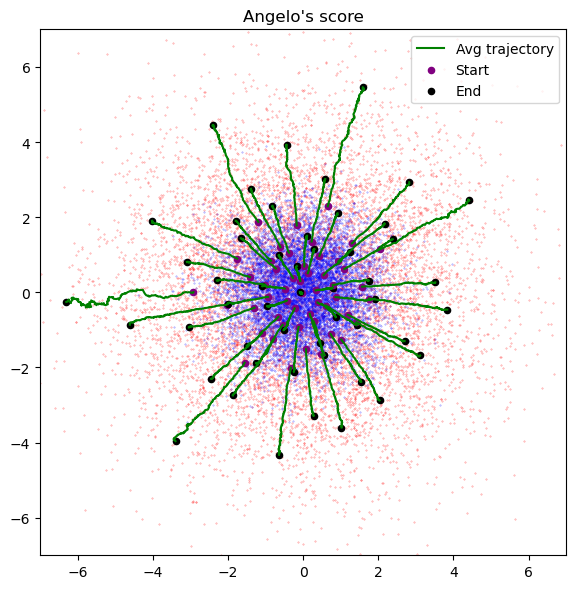

In [21]:
fig, axes = plt.subplots(1, 1, figsize=(18, 6))


# Trajectory
axes.scatter(final_positions1[:10000,0], final_positions1[:10000,1], s=0.1, alpha=0.5, color='red')
axes.scatter(initial_positions[:10000,0], initial_positions[:10000:,1], s=0.1, alpha=0.5, color='blue')
for center in range(small_region_centers1.shape[0]):
    axes.plot(avg_paths1[:, center, 0], avg_paths1[:, center, 1], 'g-', lw=1.5, label='Avg trajectory' if center == 0 else None)
    axes.scatter(avg_paths1[0, center, 0], avg_paths1[0, center, 1], color='purple', s=20, label='Start'  if center == 0 else None)
    axes.scatter(avg_paths1[-1, center, 0], avg_paths1[-1, center, 1], color='black', s=20, label='End'  if center == 0 else None)
axes.set_title("Angelo's score")
axes.legend()
axes.set_aspect('equal', adjustable='box')
axes.set_xlim(-7., 7.)
axes.set_ylim(-7., 7.)

plt.savefig("GaussianDiffusion.pdf")
plt.tight_layout()
plt.show()

In [ ]:
particlesPerCircleNormalized1 = particlesPerCircle1 / particlesPerCircle1[0, :]

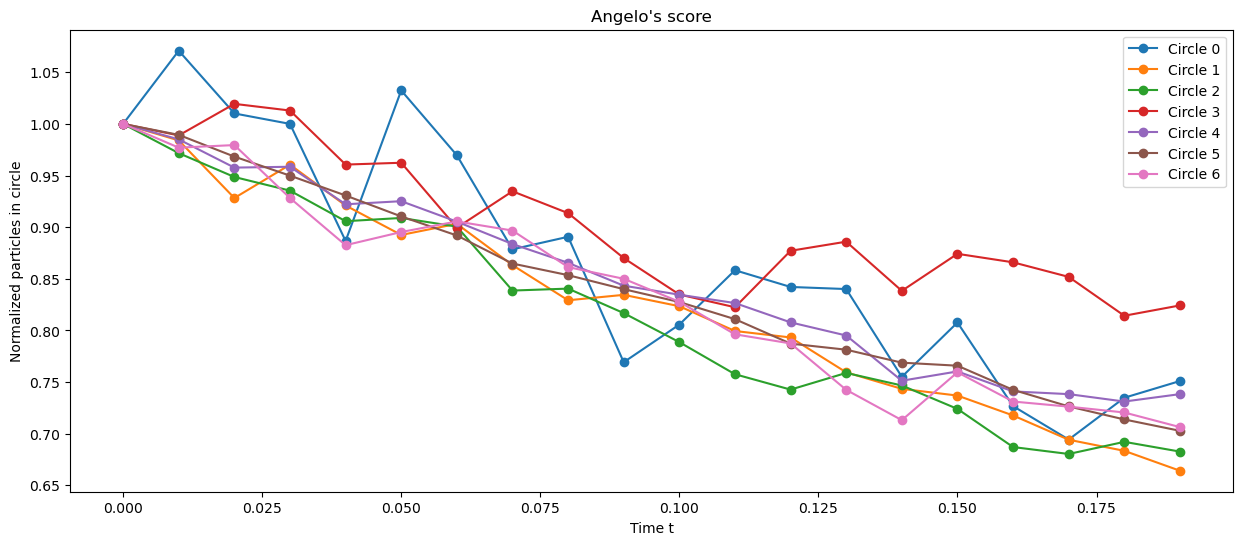

In [ ]:
fig, axes = plt.subplots(1, 1, figsize=(15, 6))

timeRange = np.arange(num_steps) * dt

# Trajectory
axes.plot(timeRange, particlesPerCircleNormalized1[:, 0], 'o-', label='Circle 0')
axes.plot(timeRange, particlesPerCircleNormalized1[:, 1], 'o-', label='Circle 1')
axes.plot(timeRange, particlesPerCircleNormalized1[:, 2], 'o-', label='Circle 2')
axes.plot(timeRange, particlesPerCircleNormalized1[:, 3], 'o-', label='Circle 3')
axes.plot(timeRange, particlesPerCircleNormalized1[:, 4], 'o-', label='Circle 4')
axes.plot(timeRange, particlesPerCircleNormalized1[:, 5], 'o-', label='Circle 5')
axes.plot(timeRange, particlesPerCircleNormalized1[:, 6], 'o-', label='Circle 6')
axes.legend()
axes.set_xlabel('Time t')
axes.set_ylabel('Normalized particles in circle')
axes.set_title("Angelo's score")

plt.show()
